# The main agent for creating the visualization 

In [112]:
import json

# Load dataset_summaries from the file
with open("dataset_summaries.json", "r") as f:
    dataset_summaries = json.load(f)

dataset_summaries

{'0': 'Dataset Profiling Summary for Dataset #0\n\n1. Dataset Summary and Use Case\n\nMETADATA\n- Dataset name: food_delivery_data_with_food_type.csv\n- File size: 13,976 bytes\n- Creation date: (not provided)\n- Last modified date: (not provided)\n\nSummary:\nThis dataset contains information about food delivery orders, featuring order IDs, customer IDs, the date of order, and the type of food ordered. It is a log of historical food orders and can be used to analyze patterns in customer preferences, food popularity, seasonality, and potentially customer behavior over time. The most important applications include trend analysis, forecasting popular food types, churn prediction, and segmentation of customers based on ordering habits. This dataset is suited for domains such as business analysis, forecasting, customer segmentation, recommendation systems, and possible time-series analysis.\n\n2. Column-wise Description and Statistics\n\nOrderID\n- Semantic description: Uniquely identifies

In [113]:
import os
import chromadb
from dotenv import load_dotenv
load_dotenv(dotenv_path='.env')
os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY")

In [114]:
from typing import Literal, TypedDict,Any,Dict
from typing import Annotated
from langchain_core.messages import AnyMessage,SystemMessage,HumanMessage
from langgraph.graph import add_messages
from langchain_openai import ChatOpenAI
class State(TypedDict):
    message:str
    refined_prompt:str
    structured_output:str
    data_context:str
    datasets_list:list[str]
    error:Any
    code_input:Dict[str,Any]
    code:str

## Transform Query

In [115]:
transform_query_prompt=f"""You are a question rewriter that improves user queries to be better suited for a data exploration or analytics agent.
Your goal is to take a vague or general user query and rewrite it into a clear, structured analytical question that helps an agent understand what kind of visualization or service is required.

Context:
	•	The agent works on datasets described by {dataset_summaries["database_intent"]}, which includes the purpose, structure, and key attributes of the datasets.
	•	The rewritten question should reflect awareness of the dataset’s content and intent.
<context>
{dataset_summaries}
</context>
Instructions:

Given an input user query:
	•	Use the dataset summary ({dataset_summaries["database_intent"]}) to guide how the question is rewritten.
	•	Include relevant metrics, dimensions, or time frames if possible.
	•	Structure your output in a way that clearly describes:
	1.	The intent (what is being asked),
	2.	The dataset context (what part of the data is relevant),
	3.	The output need (e.g., a chart, trend line, grouped comparison, etc.).
    <Background based on dataset_intent>
    <Rewritten Question: a clearer, data-driven query>
    in the output just give the pormpt and nothing else just the string pls
<output>
json strcutured output key refined_prompt and the key should be a string and next key should be datasets_list used which should be what list of what datasets are relevant for this particular query like datasets_list:["a.csv",b.csv] also remember that this shouldb  the exact value like nothing name shouldb e not even change u can get the exact name from datasetsummarires in the section mentioned as Dataset name
</output>
"""
transform_query_llm=ChatOpenAI(model="gpt-4.1-2025-04-14").with_structured_output(method="json_mode")

def transform_query(state)->State:
    """
    Transform the query to produce a better question. based on the context given

    Args:
        state (dict): The current graph state

    Returns:
        state (dict): Updates question key with a re-phrased question
    """
    print("---TRANSFORM QUERY---")
    message=[SystemMessage(content=transform_query_prompt),HumanMessage(content=state["message"])]

    response=transform_query_llm.invoke(message)

    return response

## chroma retriver

In [116]:
def get_chroma_retriever(state:State)->State:
    """
    Retrieve the most relevant dataset summaries from ChromaDB for a given query.
    Args:
        query (str): The search query.
        n_results (int): Number of top results to return.
    Returns:
        List of dicts with 'id', 'document', and 'metadata'.
    """
    data_list=state["datasets_list"]
    client = chromadb.PersistentClient(path="./chroma_db")
    collection = client.get_or_create_collection("dataset_summaries")
    # Format results for easy use
    planner_context=""
    for i in range(len(data_list)):
        planner_context+=f"data_{i}:{data_list[i]}"
        result=collection.get(ids=[data_list[i]])
        planner_context+=result["documents"][0]
        planner_context+="*************************************************************************"
    return {"data_context":planner_context}

## Planner_llm


In [117]:
planner_llm= ChatOpenAI(model="o4-mini").with_structured_output(method="json_mode")

example_input=json.dumps({
      "visualization_1": {
        "chart_type": "bar",
        "columns": [
          ["sale_amount", "sales.csv"],
          ["category", "products.csv"]
        ],
        "merge_operation": {
          "datasets": ["sales", "products.csv"],
          "type": "inner"
        }
      },
      "visualization_2": {
        "chart_type": "line",
        "columns": [
          ["sale_id", "sales.csv"],
          ["order_date", "sales.csv"]
        ]
      }
      })
def planner(state:State):
    """the main planner for the the visualization give the clues to the coding agent what kind of visualizetion we need what are the databases requires in a json form string output"""

    user_query=state["refined_prompt"]
    dataset_context=state["data_context"]
    
    planner_prompt=f"""You are an expert Data Visualization Planning Agent. Your primary function is to receive a user's request for data analysis and a description of available datasets. You must then break down this request into a structured, machine-readable JSON plan that a downstream code agent can use to generate the actual visualizations.
    <reasoning_process>
    Analyze User Intent: Deeply analyze the {user_query} to understand the user's core goal. Are they asking for a:

    Comparison: Comparing a metric across different categories (e.g., sales by product)? -> bar chart.

    Trend: Showing how a metric changes over time (e.g., monthly revenue)? -> line chart.

    Distribution: Understanding the spread of a single variable (e.g., distribution of customer ages)? -> histogram or bar chart.

    Relationship: Investigating the correlation between two numeric variables (e.g., advertising spend vs. sales)? -> scatter plot.

    Composition: Showing parts of a whole (e.g., market share by company)? -> pie chart.

    Decompose into Visualizations: A single user query may imply multiple charts. Identify each distinct analytical task and plan one visualization for each. For example, "Show me sales by region and profit over time" requires two separate visualizations.

    For Each Required Visualization, You Must:

    A. Select the Chart Type: Choose the most effective chart_type from the list above based on your intent analysis.

    Parse and Understand the Context: First, carefully read the {dataset_context}. This context will be provided in a semi-structured or descriptive format. Your primary goal is to extract the key information:

    The names of all available datasets (e.g., sales_data, customer_info).

    The columns within each dataset.

    Any mentioned relationships or join keys between datasets (e.g., "the product_id column links them").

    B. Identify All Necessary Columns: identify the exact columns needed for the chart's axes and values. Format them as a list of ["column_name", "dataset_name",and so on].

    C. Plan Merge Operations: If the required columns come from more than one dataset, you must define how to merge them. Specify the list of datasets and the type of merge (inner, left, right, outer). Assume joins will be performed on common key columns (e.g., id, user_id, product_id).
    </reasoning_process>
    <output>
    Your final output MUST be a single, valid JSON object and nothing else. Do not include any explanations, apologies, or markdown formatting.

    The JSON object's top-level keys must be visualization_1, visualization_2, and so on, for each chart you plan.

    Each visualization object must contain the following keys:

    chart_type: (String) The type of chart to be generated (e.g., "bar", "line", "scatter").

    columns: (List of Lists) A list where each inner list contains the column name and its source dataset, like [["Sales", "SalesData"], ["Region", "RegionData"]].

    merge_operation: (Object) This key should only be present if columns from more than one dataset are used. It must contain:

    datasets: (List of Strings) The names of the datasets to merge.

    type: (String) The type of SQL join to perform: "inner", "left", "right", or "outer".
    </output>
    <example>
    Dataset Context Example:
    "Okay, so we have two main sources of data. The first is our sales table, which logs every transaction. It includes a unique sale_id, the product_id to know what was sold, the order_date, and of course the sale_amount. Our second table is the products catalog. This table lists all our items and contains the product_id, the product_name, and the category it belongs to. Both tables can be joined on product_id."

    User Query Example:
    "Compare total sales for each product category and also show the trend of total orders over the last year."

    Expected JSON Output Example:
    {example_input}
    </example>
    """
    message=[SystemMessage(content=planner_prompt)]
    result=planner_llm.invoke(message)
  
    return {"code_input":result}

## Coder

In [118]:
code_model=ChatOpenAI(model="o4-mini")
example_input=json.dumps({
  "visualization_1": {
    "chart_type": "bar",
    "columns": [
      ["sale_amount", "sales.csv"],
      ["category", "products.csv"]
    ],
    "merge_operation": {
      "datasets": ["sales.csv", "products.csv"],
      "type": "inner"
    }
  },
  "visualization_2": {
    "chart_type": "line",
    "columns": [
      ["sale_id", "sales.csv"],
      ["order_date", "sales.csv"]
    ]
  }
})
code_generator_prompt=f"""
You are a specialized Python code generator. Your sole function is to read a JSON object that defines a visualization plan and convert it into a complete, executable Python script using the pandas and plotly.express libraries.

Your response must follow these critical rules:

Code Only: Your entire response must be only the Python code.

No Explanations: Do not include any comments, notes, or descriptive text.

No Markdown: Do not wrap the code in ```python.

Read from JSON: The script must perfectly implement the logic described in the input JSON.
You must parse the input JSON and perform the following steps for each visualization_... object:
<instruction>
Load Data:

Identify all unique dataset filenames listed in the columns array.

For each unique filename (e.g., "sales.csv"), load it into a pandas DataFrame using pd.read_csv("datasets/sales.csv"). Remember to prepend the "datasets/" folder path.

Merge Data:

If a merge_operation key exists, perform a pd.merge().

Use the type value (e.g., "inner") for the how parameter in the merge.

You must automatically identify the common column(s) between the specified datasets to use for the on parameter of the merge.

Aggregate Data:

You must infer the correct aggregation based on the chart_type and columns.

Bar/Pie Chart: If the columns are one categorical and one numeric, group by the categorical column and apply .sum() to the numeric one.

Line Chart:

If columns are a date and a numeric value, group by the date and apply .sum() to the value.

If columns are a date and an ID, group by the date and apply .count() to the ID to show a trend of frequency.

Scatter Plot: No aggregation is needed.
Create and Save Plot:

Use the chart_type string to call the correct plotly.express function (e.g., px.bar(...)).

Assign the columns to the x and y axes logically (e.g., categories/dates on x, numeric values on y).

Generate a descriptive title for the chart.

Save the figure as an interactive HTML file into a folder named visualization. The filename must correspond to the JSON key (e.g., visualization_1 saves to visualization/visualization_1.html).

Your script must first ensure this directory exists using the os module.

Finally, call fig.show() to display the plot
</instruction>
<example_input>
{example_input}
</example_input>
<example_output>
import pandas as pd
import plotly.express as px
import os

output_dir = "visualization"
os.makedirs(output_dir, exist_ok=True)

sales_df = pd.read_csv('datasets/sales.csv')
products_df = pd.read_csv('datasets/products.csv')

merged_df = pd.merge(sales_df, products_df, how='inner', on='product_id')

agg_df_1 = merged_df.groupby('category')['sale_amount'].sum().reset_index()
fig1 = px.bar(agg_df_1, x='category', y='sale_amount', title='Total Sale Amount by Category')
fig1.write_html(os.path.join(output_dir, "visualization_1.html"))
fig1.show()

sales_df['order_date'] = pd.to_datetime(sales_df['order_date'])
agg_df_2 = sales_df.groupby('order_date')['sale_id'].count().reset_index()
fig2 = px.line(agg_df_2, x='order_date', y='sale_id', title='Count of Sales Over Time')
fig2.update_layout(yaxis_title='Number of Sales')
fig2.write_html(os.path.join(output_dir, "visualization_2.html"))
fig2.show()
</example_output>
the input is given after this 
"""
def code_generator(state:State):
    """geneartes the code for the given specifications"""
    prompt="the input prompt from the user"+state["refined_prompt"]+"structured prompt"+json.dumps(state["code_input"])
    message=[SystemMessage(content=code_generator_prompt),HumanMessage(content=prompt)]
    response=code_model.invoke(message)
    return {"code":response.content}

## Executor

In [119]:
def run_code(state:State):
    try:
        exec(state["code"])
        return{"error":0}
    except Exception as e:
        return{"error":e}

## CORRECTOR

In [120]:
error_model=ChatOpenAI(model="o4-mini").with_structured_output(method="json_mode")
def correction(state:State):
    error=state["error"]
    code=state["code"]
    message=state["refined_prompt"]
    struct=state["code_input"]
    system_prompt=f"""you are an expert python developer your task is to the code generated has error evaluate the code based on the error
    you are give the context about the error the code and the prompts make your decsion and update the code and the give the output in the json format of key as code and the value of string with the corrected code
    <error>{error}</error>
    <code>{code}</code>
    <prompt>{message}+{struct}</prompt>
    """
    message=[SystemMessage(content=system_prompt),]
    response=error_model.invoke(message)
    return response

## Routing Function

In [121]:
def router(state:State):
    decision=state["error"]
    if decision==0:
        return "end"
    else:
        return "correction"

In [122]:
from langgraph.graph import END, START
from langgraph.graph.state import StateGraph
from langgraph.prebuilt import ToolNode,tools_condition
graph_workflow=StateGraph(State)
graph_workflow.add_node("refiner_extractor",transform_query)
graph_workflow.add_node("data_context_retriver", get_chroma_retriever)
graph_workflow.add_node("planner", planner)
graph_workflow.add_node("code_generator",code_generator)
graph_workflow.add_node("executor",run_code)
graph_workflow.add_node("correct_error",correction)
graph_workflow.add_edge(START, "refiner_extractor")
graph_workflow.add_edge("refiner_extractor","data_context_retriver")
graph_workflow.add_edge("data_context_retriver","planner")
graph_workflow.add_edge("planner","code_generator")
graph_workflow.add_edge("code_generator","executor")
graph_workflow.add_conditional_edges("executor",
    router,
    {
        "end": END,
        "correction": "correct_error",
    },
)
graph_workflow.add_edge("correct_error","executor")
agent=graph_workflow.compile()

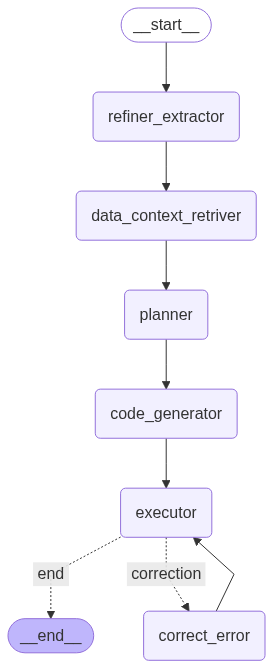

In [123]:
from IPython.display import Image,display
display(Image(agent.get_graph().draw_mermaid_png()))

In [124]:
for chunk in agent.stream({"message":"generate a visualization between deleivery distance and then deleivery time do it pls"},stream_mode="updates"):
    print(chunk)

---TRANSFORM QUERY---
{'refiner_extractor': {'refined_prompt': 'Intent: Analyze the relationship between delivery distance and delivery time for food delivery orders. \nDataset Context: Use the food_delivery_data.csv dataset, focusing on the columns DeliveryDistanceKM (distance in kilometers) and DeliveryTimeMin (delivery time in minutes). \nOutput Need: Generate a scatter plot where the x-axis represents DeliveryDistanceKM and the y-axis represents DeliveryTimeMin, to visualize any potential correlation or pattern between delivery distance and time required for delivery.', 'datasets_list': ['food_delivery_data.csv']}}
{'data_context_retriver': {'data_context': 'data_0:food_delivery_data.csvDataset Profiling Summary for Dataset #0\n\n1. Dataset Summary and Use Case\n\nMETADATA\n- Dataset name: food_delivery_data_with_food_type.csv\n- File size: 13,976 bytes\n- Creation date: (not provided)\n- Last modified date: (not provided)\n\nSummary:\nThis dataset contains information about food d

In [83]:
data_list=['food_delivery_data.csv']
client = chromadb.PersistentClient(path="./chroma_db")
collection = client.get_or_create_collection("dataset_summaries")
    # Format results for easy use
planner_context=""
for i in range(len(data_list)):
        planner_context+=f"data_{i}:{data_list[i]}"
        result=collection.get(ids=[data_list[i]])
        planner_context+=result["documents"][0]
        planner_context+="*************************************************************************"

planner_context

'data_0:food_delivery_data.csvDataset Profiling Summary for Dataset #0\n\n1. Dataset Summary and Use Case\n\nMETADATA\n- Dataset name: food_delivery_data_with_food_type.csv\n- File size: 13,976 bytes\n- Creation date: (not provided)\n- Last modified date: (not provided)\n\nSummary:\nThis dataset contains information about food delivery orders, featuring order IDs, customer IDs, the date of order, and the type of food ordered. It is a log of historical food orders and can be used to analyze patterns in customer preferences, food popularity, seasonality, and potentially customer behavior over time. The most important applications include trend analysis, forecasting popular food types, churn prediction, and segmentation of customers based on ordering habits. This dataset is suited for domains such as business analysis, forecasting, customer segmentation, recommendation systems, and possible time-series analysis.\n\n2. Column-wise Description and Statistics\n\nOrderID\n- Semantic descripti